# Exploratory Data Analysis Notebook

This notebook explores the main factors associated with historical ride cost in the cleaned dynamic-pricing ride-sharing dataset.

The analysis addresses the following questions:

1. How does historical ride cost differ across vehicle types, location categories, booking times, and customer loyalty groups?
2. How are expected ride duration, number of past rides, and average customer ratings associated with historical ride cost?

Two demand-and-supply variables are also prepared for the team member responsible for the detailed demand-and-supply analysis.

## Import Libraries

Importing the libraries needed for data analysis and visualization

In [124]:
import pandas as pd 
import matplotlib.pyplot as plt 
import os 

In [125]:
def plot_bar_chart(series, title, xlabel, ylabel):

    plt.bar(series.index, series.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.show()

## Load Cleaned Dataset

Loading the cleaned dataset that was saved during the data cleaning step

In [126]:
cleaned_file_path = "../Data/Cleaned/cleaned_dynamic_pricing.csv"

if os.path.exists(cleaned_file_path):
    df = pd.read_csv(cleaned_file_path)
    print("Cleaned dataset loaded successfully.")
else:
    raise FileNotFoundError("The cleaned dataset could not be found.")

df.head()

Cleaned dataset loaded successfully.


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


## Dataset Overview

Checking the size of the cleaned dataset and reviewing the main summary statistics


In [127]:
df.shape

(1000, 10)

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


In [129]:
df.describe()

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


The cleaned dataset contains 1,000 observations and 10 variables. Six variables are numerical and four are categorical. The dataset includes information about demand, supply, customer history, customer ratings, booking conditions, ride duration, vehicle type, and historical ride cost.

## Dataset Structure and Categorical Overview

This section provides a compact overview of the data types, missing values, unique values, and category frequencies

In [130]:
structure_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

structure_summary

,Column,Data Type,Missing Values,Unique Values
0,Number_of_Riders,int64,0,81
1,Number_of_Drivers,int64,0,79
2,Location_Category,object,0,3
3,Customer_Loyalty_Status,object,0,3
4,Number_of_Past_Rides,int64,0,101
5,Average_Ratings,float64,0,151
6,Time_of_Booking,object,0,4
7,Vehicle_Type,object,0,2
8,Expected_Ride_Duration,int64,0,171
9,Historical_Cost_of_Ride,float64,0,1000


The following section checks the distribution of categorical variables using unique values and value counts

In [131]:
categorical_columns = [
    "Location_Category",
    "Customer_Loyalty_Status",
    "Time_of_Booking",
    "Vehicle_Type"
]

for col in categorical_columns:
    print(f"\n{col}")
    print("Unique values:", df[col].unique())
    print(df[col].value_counts())


Location_Category
Unique values: ['Urban' 'Suburban' 'Rural']
Location_Category
Urban       346
Rural       332
Suburban    322
Name: count, dtype: int64

Customer_Loyalty_Status
Unique values: ['Silver' 'Regular' 'Gold']
Customer_Loyalty_Status
Silver     367
Regular    320
Gold       313
Name: count, dtype: int64

Time_of_Booking
Unique values: ['Night' 'Evening' 'Afternoon' 'Morning']
Time_of_Booking
Night        276
Afternoon    247
Morning      246
Evening      231
Name: count, dtype: int64

Vehicle_Type
Unique values: ['Premium' 'Economy']
Vehicle_Type
Premium    522
Economy    478
Name: count, dtype: int64


The displayed values match the expected categorical labels. The category counts sum to 1,000 observations for each categorical variable, which is consistent with the absence of missing values.

## Feature Preparation for Team Analysis

Two demand-and-supply variables are created for the team member responsible for the detailed demand-and-supply analysis. These variables are prepared here but are not interpreted in this notebook.

In [132]:
df["Demand_Supply_Ratio"] = df["Number_of_Riders"] / df["Number_of_Drivers"]

df["Demand_Supply_Difference"] = df["Number_of_Riders"] - df["Number_of_Drivers"]

df[["Demand_Supply_Ratio", "Demand_Supply_Difference"]].head()

,Demand_Supply_Ratio,Demand_Supply_Difference
0,2.000000,45
1,1.487179,19
2,1.354839,11
3,3.178571,61
4,3.545455,56


`Demand_Supply_Ratio` compares the number of riders with the number of available drivers. `Demand_Supply_Difference` calculates the numerical gap between riders and drivers. The detailed interpretation of these variables is completed by another team member.

### Save Dataset with Added Columns

The dataset containing the two prepared demand-and-supply variables is saved so that it can be used in later parts of the group project.

In [133]:
featured_file_path = "../Data/Cleaned/cleaned_dynamic_pricing_with_features.csv"

df.to_csv(featured_file_path, index=False)

if os.path.exists(featured_file_path):
    print("Dataset with added columns saved successfully.")
else:
    print("File was not saved.")

Dataset with added columns saved successfully.


## Summary of New Columns

In [134]:
df[["Demand_Supply_Ratio", "Demand_Supply_Difference"]].describe()

,Demand_Supply_Ratio,Demand_Supply_Difference
count,1000.000000,1000.000000
mean,3.235461,33.296000
std,2.533519,18.936869
min,1.112360,10.000000
25%,1.658793,18.000000
50%,2.357143,28.000000
75%,3.800000,45.250000
max,17.600000,93.000000


The summary confirms that both demand-and-supply variables were created successfully. Their detailed analysis and interpretation are completed by the team member responsible for demand-and-supply analysis.

## Distribution of Historical Ride Cost

Examining the distribution of historical ride cost since this is the main pricing variable in the dataset

In [135]:
df["Historical_Cost_of_Ride"].describe()

count    1000.000000
mean      372.502623
std       187.158756
min        25.993449
25%       221.365202
50%       362.019426
75%       510.497504
max       836.116419
Name: Historical_Cost_of_Ride, dtype: float64

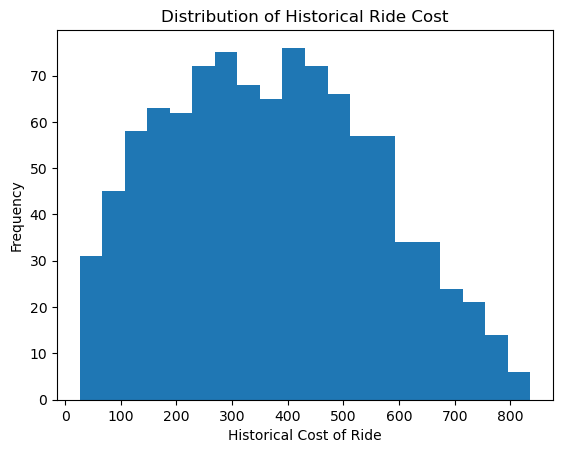

In [136]:
plt.hist(df["Historical_Cost_of_Ride"], bins=20)

plt.title("Distribution of Historical Ride Cost")
plt.xlabel("Historical Cost of Ride")
plt.ylabel("Frequency")
plt.show()

Historical ride cost has a mean of approximately 372.50 and a median of approximately 362.02. The middle 50% of ride costs lie between approximately 221.37 and 510.50. The histogram shows substantial variation in historical ride costs, with fewer observations close to the minimum and maximum values.

## Average Ride Cost by Category

Comparing the average historical ride cost across categorical variables to understand which groups have higher or lower ride costs

In [137]:
vehicle_summary = (
    df.groupby("Vehicle_Type")["Historical_Cost_of_Ride"].agg(["count", "mean", "median"]).round(2))

vehicle_summary

,count,mean,median
Vehicle_Type,,,
Economy,478,346.57,331.23
Premium,522,396.25,397.59


In [138]:
location_summary = (
    df.groupby("Location_Category")["Historical_Cost_of_Ride"].agg(["count", "mean", "median"]).round(2))

location_summary

,count,mean,median
Location_Category,,,
Rural,332,379.94,367.76
Suburban,322,374.32,362.70
Urban,346,363.67,359.96


In [139]:
time_summary = (
    df.groupby("Time_of_Booking")["Historical_Cost_of_Ride"].agg(["count", "mean", "median"]).round(2)
)

time_summary

,count,mean,median
Time_of_Booking,,,
Afternoon,247,380.82,387.48
Evening,231,364.25,360.71
Morning,246,378.06,382.23
Night,276,367.01,336.09


In [140]:
loyalty_summary = (
    df.groupby("Customer_Loyalty_Status")["Historical_Cost_of_Ride"].agg(["count", "mean", "median"]).round(2))

loyalty_summary

,count,mean,median
Customer_Loyalty_Status,,,
Gold,313,376.12,373.98
Regular,320,380.13,358.95
Silver,367,362.77,348.67


## Average Ride Cost by Vehicle Type

Creating a bar chart to compare the average historical ride cost between vehicle types.

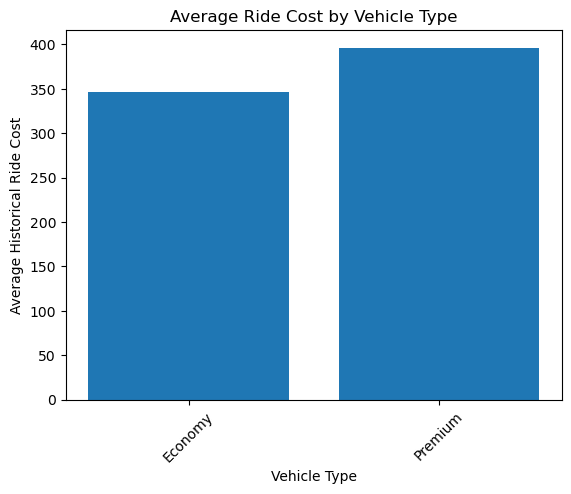

In [141]:
vehicle_cost = df.groupby("Vehicle_Type")["Historical_Cost_of_Ride"].mean().round(2)

plot_bar_chart(
    vehicle_cost, "Average Ride Cost by Vehicle Type", "Vehicle Type", "Average Historical Ride Cost"
)



## Average Ride Cost by Location Category

Creating a bar chart to compare the average historical ride cost across location categories

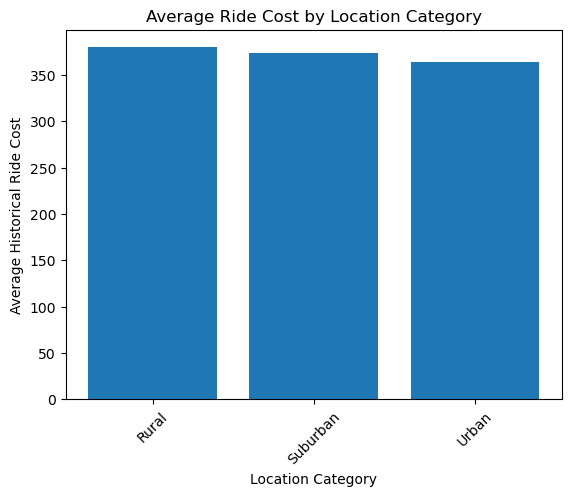

In [142]:
location_cost = (df.groupby("Location_Category")["Historical_Cost_of_Ride"].mean().round(2))

plot_bar_chart(location_cost,"Average Ride Cost by Location Category","Location Category","Average Historical Ride Cost")

## Average Ride Cost by Time of Booking

Creating a bar chart to compare the average historical ride cost across different booking times

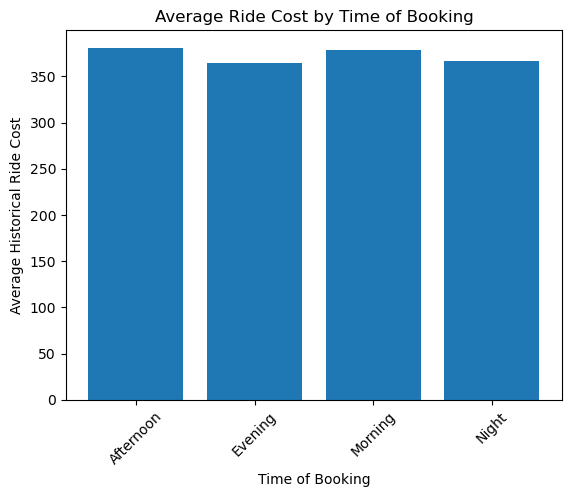

In [143]:
time_cost = df.groupby("Time_of_Booking")["Historical_Cost_of_Ride"].mean().round(2)


plot_bar_chart(
    time_cost, "Average Ride Cost by Time of Booking", "Time of Booking", "Average Historical Ride Cost"
)

## Average Ride Cost by Customer Loyalty Status

Creating a bar chart to compare the average historical ride cost across customer loyalty groups

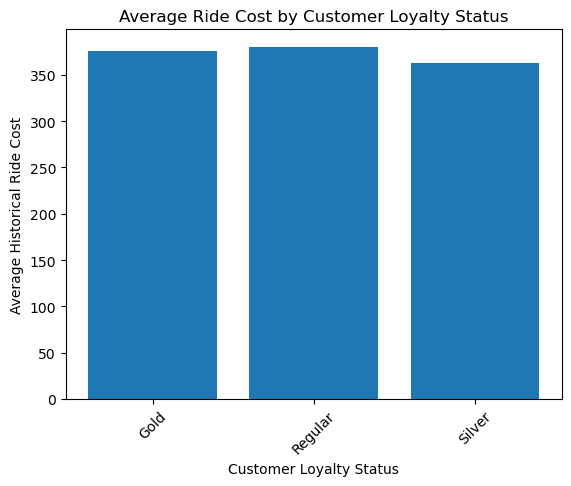

In [144]:
loyalty_cost = df.groupby("Customer_Loyalty_Status")["Historical_Cost_of_Ride"].mean().round(2)

plot_bar_chart(
    loyalty_cost, "Average Ride Cost by Customer Loyalty Status", "Customer Loyalty Status", "Average Historical Ride Cost"
)

Premium rides have an average historical cost of approximately 396.25, compared with approximately 346.57 for economy rides. This difference of approximately 49.68 is the largest observed difference among the categorical comparisons.

Rural rides have the highest average among the location categories, while afternoon and morning bookings have slightly higher averages than evening and night bookings. Customer loyalty groups show relatively small differences in average historical ride cost.

These findings describe associations in the dataset. They do not prove that the categorical variables directly cause changes in historical ride cost.

## Ride Duration and Ride Cost

Checking whether longer expected ride duration is related to higher historical ride cost

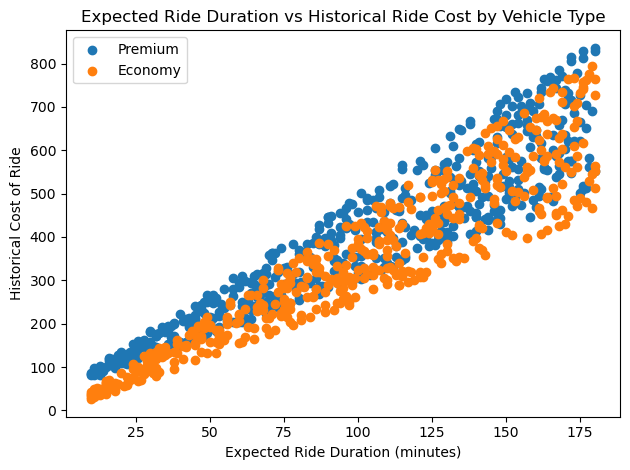

In [145]:
for vehicle_type in df["Vehicle_Type"].unique():
    vehicle_data = df[ df["Vehicle_Type"] == vehicle_type]

    plt.scatter(
        vehicle_data["Expected_Ride_Duration"],
        vehicle_data["Historical_Cost_of_Ride"],
        label=vehicle_type
    )

plt.title(
    "Expected Ride Duration vs Historical Ride Cost "
    "by Vehicle Type"
)
plt.xlabel("Expected Ride Duration (minutes)")
plt.ylabel("Historical Cost of Ride")
plt.legend()
plt.tight_layout()
plt.show()

The scatterplot shows a clear positive association between expected ride duration and historical ride cost. Longer rides generally have higher historical costs.

Both vehicle types follow the same upward pattern, but premium observations generally appear above economy observations at similar ride durations. This suggests that expected ride duration and vehicle type are both associated with historical ride cost. The chart shows association and does not prove causation.

## Customer History and Ride Cost

Checking whether the number of past rides is related to historical ride cost

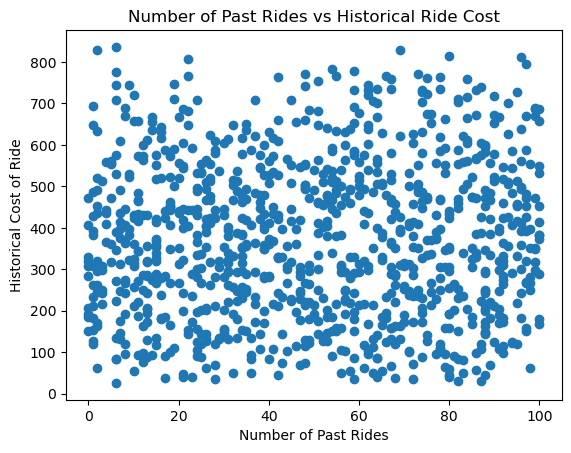

In [146]:
plt.scatter(df["Number_of_Past_Rides"], df["Historical_Cost_of_Ride"])

plt.title("Number of Past Rides vs Historical Ride Cost")
plt.xlabel("Number of Past Rides")
plt.ylabel("Historical Cost of Ride")
plt.show()

The scatterplot does not show a clear relationship between the number of past rides and historical ride cost. Customer usage history therefore does not appear to be a strong direct pricing factor in this dataset.

## Average Ratings and Ride Cost

Checking whether average customer ratings are related to historical ride cost

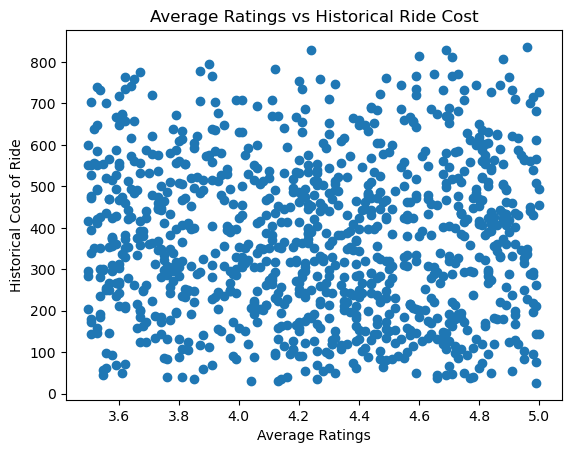

In [147]:
plt.scatter(df["Average_Ratings"], df["Historical_Cost_of_Ride"])

plt.title("Average Ratings vs Historical Ride Cost")
plt.xlabel("Average Ratings")
plt.ylabel("Historical Cost of Ride")
plt.show()

The scatterplot does not show a clear relationship between average customer ratings and historical ride cost. Average ratings therefore do not appear to be a strong direct pricing factor in this dataset.

## EDA Summary

- The cleaned dataset contains 1,000 observations and 10 original variables.

- Two additional variables, `Demand_Supply_Ratio` and `Demand_Supply_Difference`, were prepared for the team member responsible for the detailed demand-and-supply analysis.

- Historical ride cost has a mean of approximately 372.50 and a median of approximately 362.02. The middle 50% of ride costs lie between approximately 221.37 and 510.50.

- Expected ride duration shows the clearest positive relationship with historical ride cost. Longer expected rides generally have higher historical costs.

- Premium rides have a higher average historical cost than economy rides. Vehicle type shows the largest observed difference among the categorical comparisons.

- Rural rides have a slightly higher average cost than suburban and urban rides. Afternoon and morning bookings also have slightly higher averages than evening and night bookings.

- Customer loyalty groups show relatively small differences in average historical ride cost.

- Number of past rides and average customer ratings do not show clear relationships with historical ride cost.

- Overall, expected ride duration and vehicle type show the clearest relationships with historical ride cost in this part of the EDA.

- The findings describe associations within the dataset and should not be interpreted as proof of causation.